In [2]:
%pip install pandas numpy matplotlib seaborn scipy statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/workspaces/DSCI441-Project-Xirui_Ruoyan/Supplement_Sales_Weekly_Expanded.csv")
df.head()

,Date,Product Name,Category,Units Sold,Price,Revenue,Discount,Units Returned,Location,Platform
0,2020-01-06,Whey Protein,Protein,143,31.98,4573.14,0.03,2,Canada,Walmart
1,2020-01-06,Vitamin C,Vitamin,139,42.51,5908.89,0.04,0,UK,Amazon
2,2020-01-06,Fish Oil,Omega,161,12.91,2078.51,0.25,0,Canada,Amazon
3,2020-01-06,Multivitamin,Vitamin,140,16.07,2249.80,0.08,0,Canada,Walmart
4,2020-01-06,Pre-Workout,Performance,157,35.47,5568.79,0.25,3,Canada,iHerb


# EDA

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (4384, 10)

Columns:
['Date', 'Product Name', 'Category', 'Units Sold', 'Price', 'Revenue', 'Discount', 'Units Returned', 'Location', 'Platform']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            4384 non-null   str    
 1   Product Name    4384 non-null   str    
 2   Category        4384 non-null   str    
 3   Units Sold      4384 non-null   int64  
 4   Price           4384 non-null   float64
 5   Revenue         4384 non-null   float64
 6   Discount        4384 non-null   float64
 7   Units Returned  4384 non-null   int64  
 8   Location        4384 non-null   str    
 9   Platform        4384 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 342.6 KB


In [7]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct


In [8]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


## 1. Basic

### 1.1. Numerical Variables

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['Units Sold', 'Price', 'Revenue', 'Discount', 'Units Returned']

In [10]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Units Sold,4384.0,150.200274,12.396099,103.0,142.0000,150.00,158.0000,194.00
Price,4384.0,34.781229,14.198309,10.0,22.5975,34.72,46.7125,59.97
Revenue,4384.0,5226.569446,2192.491946,1284.0,3349.3725,5173.14,7009.9600,10761.85
Discount,4384.0,0.124398,0.071792,0.0,0.0600,0.12,0.1900,0.25
Units Returned,4384.0,1.531478,1.258479,0.0,1.0000,1.00,2.0000,8.00


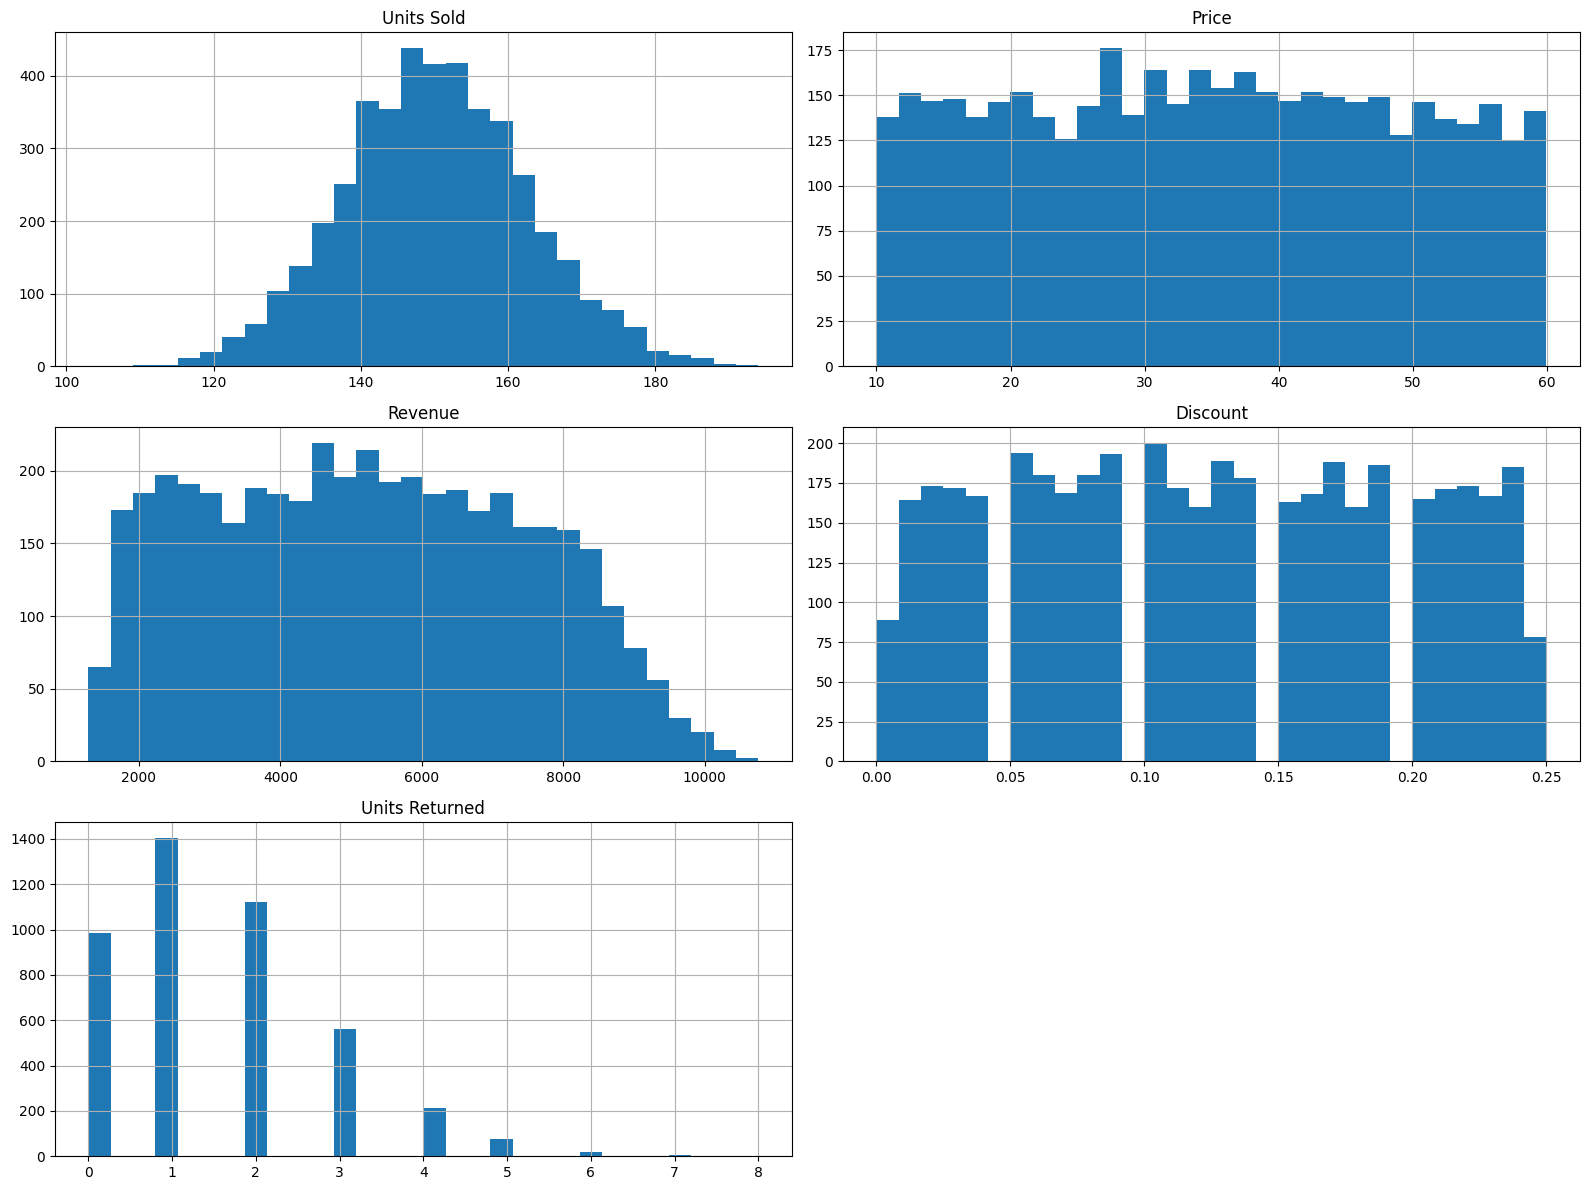

In [11]:
df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

### 1.2. Categorical Variables

In [12]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols

/tmp/ipykernel_2156/236125719.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


['Date', 'Product Name', 'Category', 'Location', 'Platform']

In [13]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Date: 274 unique values
Product Name: 16 unique values
Category: 10 unique values
Location: 3 unique values
Platform: 3 unique values


In [14]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).head(10))


Column: Date
Date
2020-01-06    16
2020-01-13    16
2020-01-20    16
2020-01-27    16
2020-02-03    16
2020-02-10    16
2020-02-17    16
2020-02-24    16
2020-03-02    16
2020-03-09    16
Name: count, dtype: int64

Column: Product Name
Product Name
Whey Protein         274
Vitamin C            274
Fish Oil             274
Multivitamin         274
Pre-Workout          274
BCAA                 274
Creatine             274
Zinc                 274
Collagen Peptides    274
Magnesium            274
Name: count, dtype: int64

Column: Category
Category
Vitamin        822
Mineral        822
Protein        548
Performance    548
Omega          274
Amino Acid     274
Herbal         274
Sleep Aid      274
Fat Burner     274
Hydration      274
Name: count, dtype: int64

Column: Location
Location
Canada    1507
UK        1475
USA       1402
Name: count, dtype: int64

Column: Platform
Platform
iHerb      1499
Amazon     1473
Walmart    1412
Name: count, dtype: int64


### 1.3. Time Variables

In [15]:
df.columns.tolist()

['Date',
 'Product Name',
 'Category',
 'Units Sold',
 'Price',
 'Revenue',
 'Discount',
 'Units Returned',
 'Location',
 'Platform']

In [16]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df["Date"].min(), df["Date"].max())

2020-01-06 00:00:00 2025-03-31 00:00:00


In [17]:
df = df.sort_values("Date")
df[["Date"]].head()

,Date
0,2020-01-06
15,2020-01-06
14,2020-01-06
13,2020-01-06
12,2020-01-06


### 1.4. Sales Distribution Analysis

In [18]:
target_col = "Units Sold"
print(df[target_col].describe())

count    4384.000000
mean      150.200274
std        12.396099
min       103.000000
25%       142.000000
50%       150.000000
75%       158.000000
max       194.000000
Name: Units Sold, dtype: float64


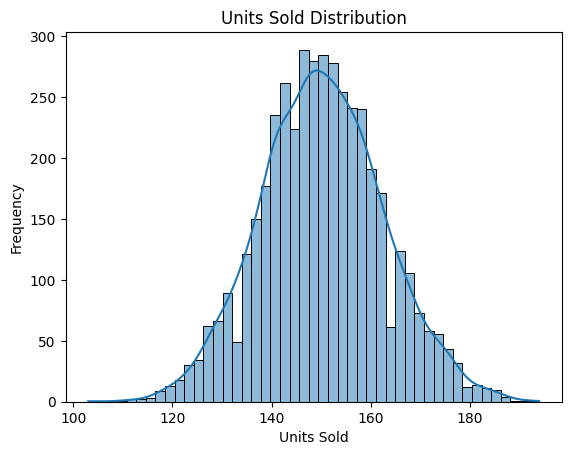

In [19]:
# plt.figure(figsize=(8,5))
# plt.hist(df[target_col], bins=30)
# plt.xlabel("Units Sold")
# plt.ylabel("Frequency")
# plt.title("Distribution of Units Sold")
# plt.show()

sns.histplot(df['Units Sold'], kde=True)

plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

## 2. Relational EDA

### 2.1. Weekly Total Units Sold Over Time

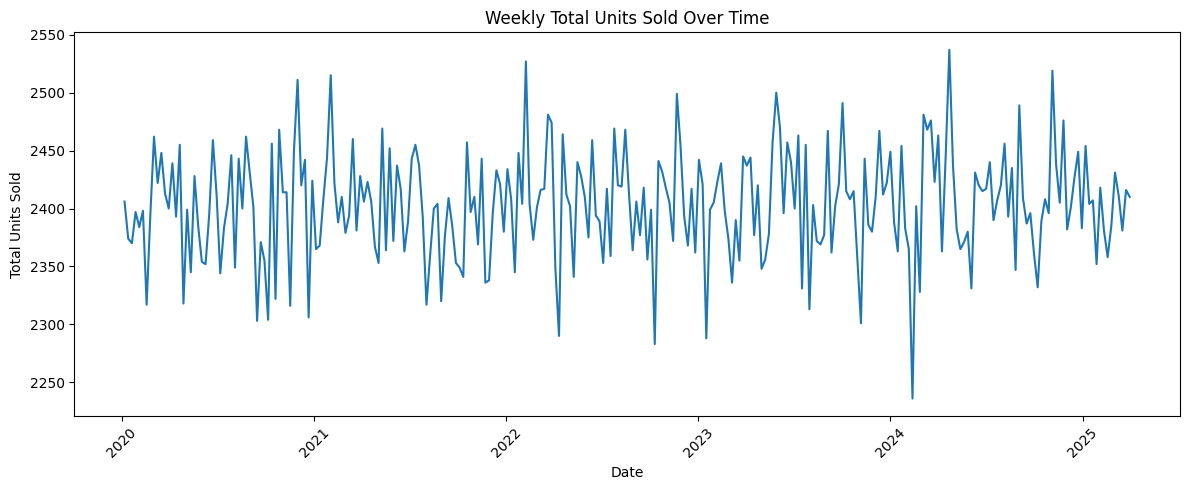

In [39]:
weekly_units = df.groupby("Date")["Units Sold"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(weekly_units["Date"], weekly_units["Units Sold"])
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.title("Weekly Total Units Sold Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.2. Total Units Sold by Category

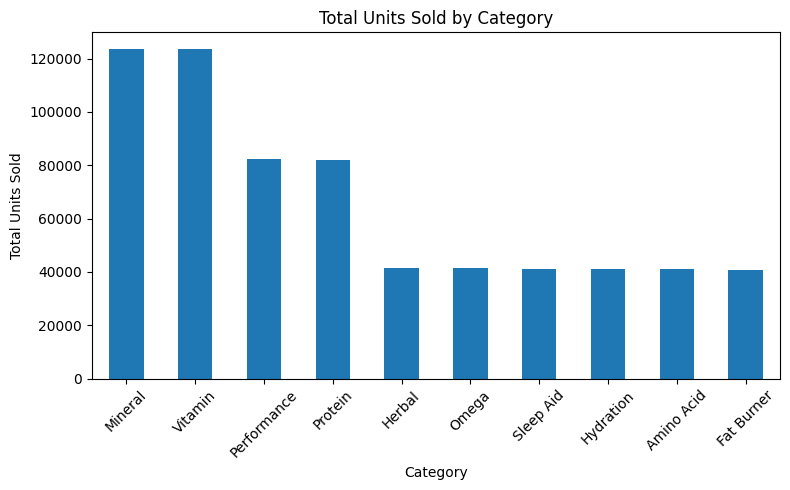

In [21]:
category_sales = df.groupby("Category")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.3. Total Units Sold by Product

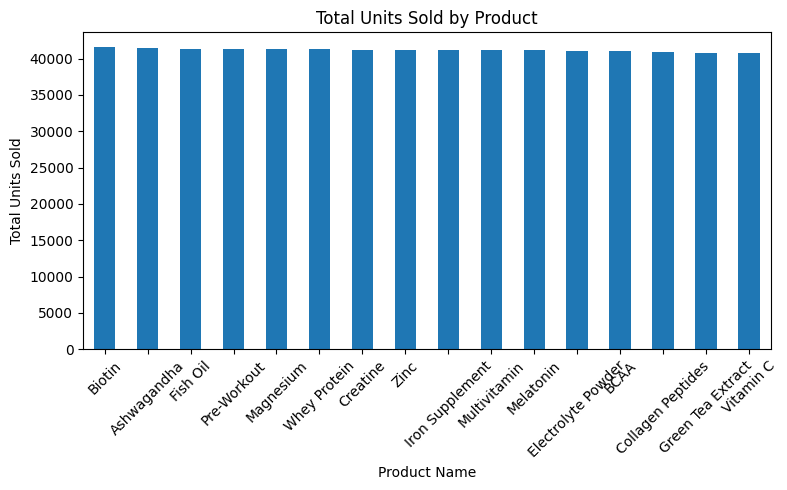

In [22]:
product_sales = df.groupby("Product Name")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
product_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.4. Total Units Sold by Location

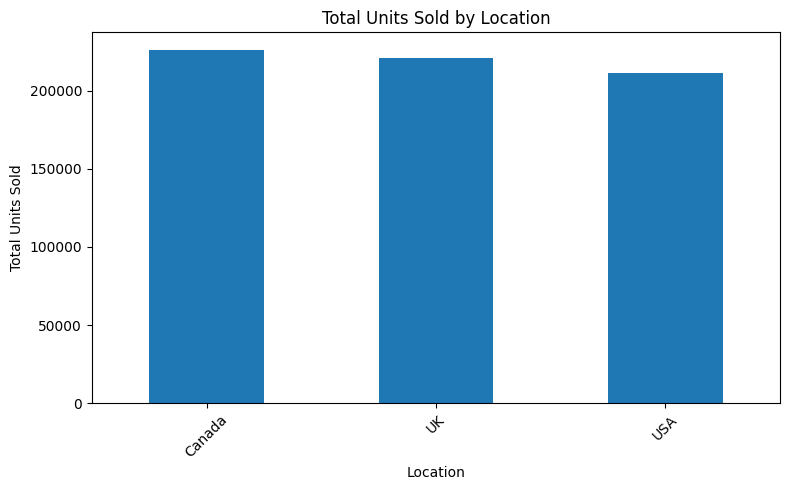

In [23]:
location_sales = df.groupby("Location")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
location_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Location")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.5. Total Units Sold by Platform

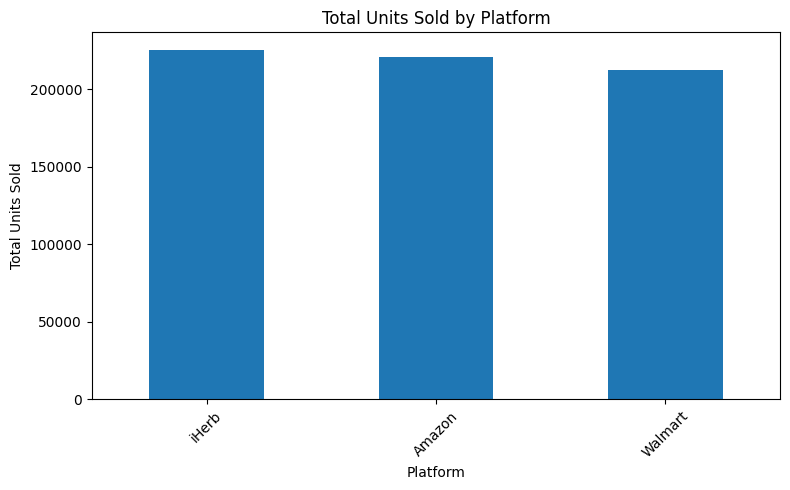

In [24]:
platform_sales = df.groupby("Platform")["Units Sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
platform_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.6. Price vs Units Sold

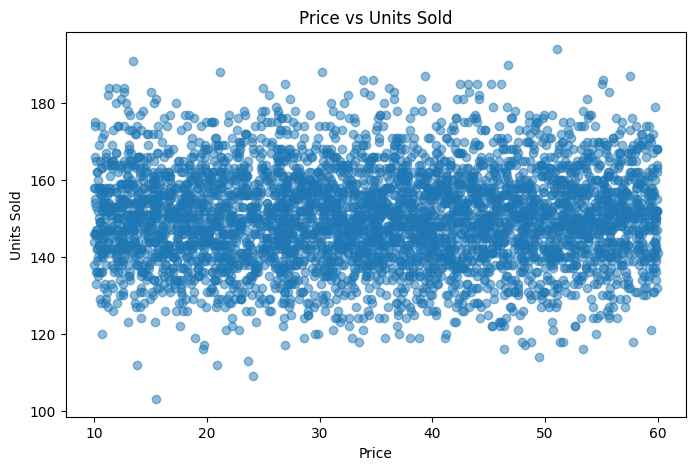

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(df["Price"], df["Units Sold"], alpha=0.5)
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Units Sold")
plt.show()

### 2.7. Discount vs Units Sold

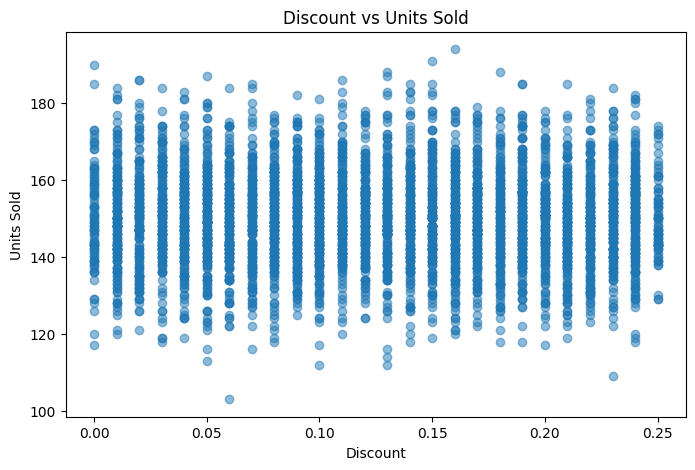

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Units Sold"], alpha=0.5)
plt.xlabel("Discount")
plt.ylabel("Units Sold")
plt.title("Discount vs Units Sold")
plt.show()

In [27]:
df.groupby("Discount")["Units Sold"].mean().sort_index()

Discount
0.00    150.617978
0.01    150.359756
0.02    150.526012
0.03    151.459302
0.04    150.119760
0.05    150.005155
0.06    149.138889
0.07    149.562130
0.08    150.161111
0.09    150.160622
0.10    150.030000
0.11    151.046512
0.12    150.931250
0.13    150.746032
0.14    150.410112
0.15    150.993865
0.16    149.678571
0.17    150.622340
0.18    149.043750
0.19    150.908602
0.20    150.169697
0.21    147.894737
0.22    148.722543
0.23    150.754491
0.24    151.059459
0.25    150.141026
Name: Units Sold, dtype: float64

### 2.8. Units Returned vs Units Sold

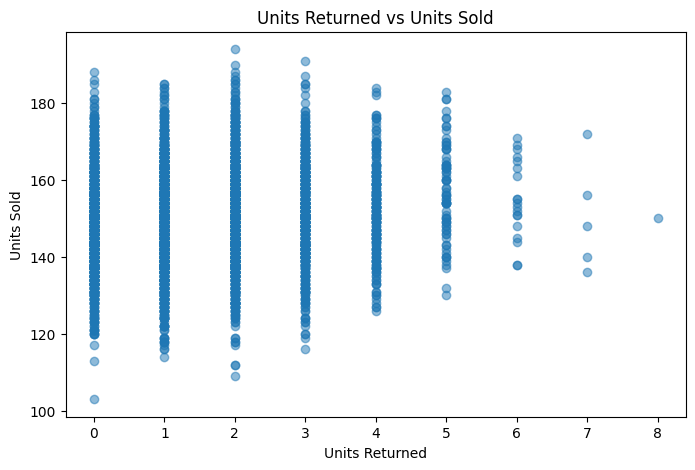

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df["Units Returned"], df["Units Sold"], alpha=0.5)
plt.xlabel("Units Returned")
plt.ylabel("Units Sold")
plt.title("Units Returned vs Units Sold")
plt.show()

### 2.9. Numerical Variable Correlation

In [29]:
numeric_cols = ["Units Sold", "Price", "Revenue", "Discount", "Units Returned"]
corr = df[numeric_cols].corr()
corr

,Units Sold,Price,Revenue,Discount,Units Returned
Units Sold,1.000000,0.013749,0.210462,-0.010435,0.116523
Price,0.013749,1.000000,0.977198,-0.008668,-0.010410
Revenue,0.210462,0.977198,1.000000,-0.012531,0.012432
Discount,-0.010435,-0.008668,-0.012531,1.000000,0.004276
Units Returned,0.116523,-0.010410,0.012432,0.004276,1.000000


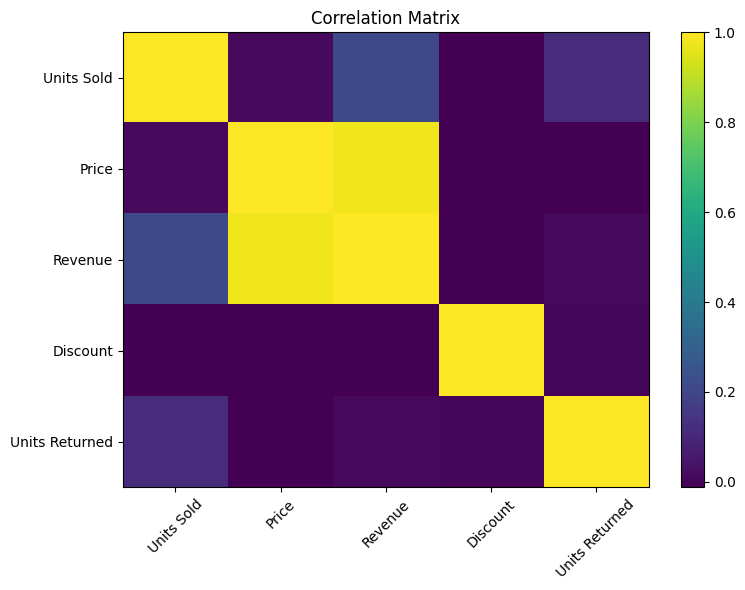

In [30]:
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 2.10. Weekly Unit sold

#### 2.10.1 By Category

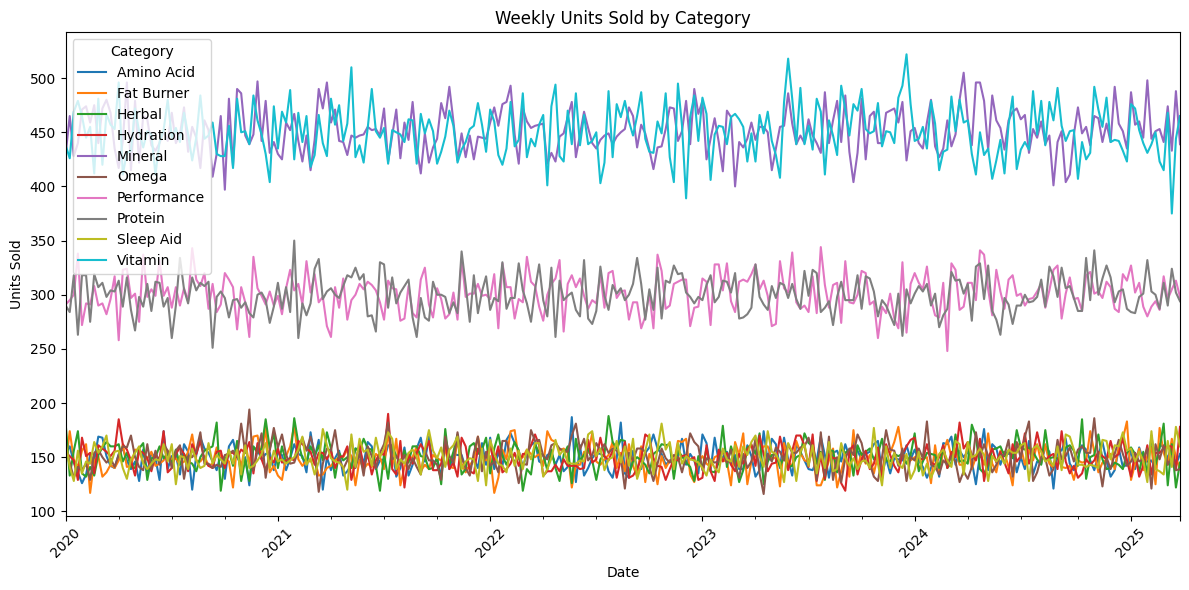

In [31]:
category_trend = df.groupby(["Date", "Category"])["Units Sold"].sum().unstack()

category_trend.plot(figsize=(12,6))
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Weekly Units Sold by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2.10.2 By Platform

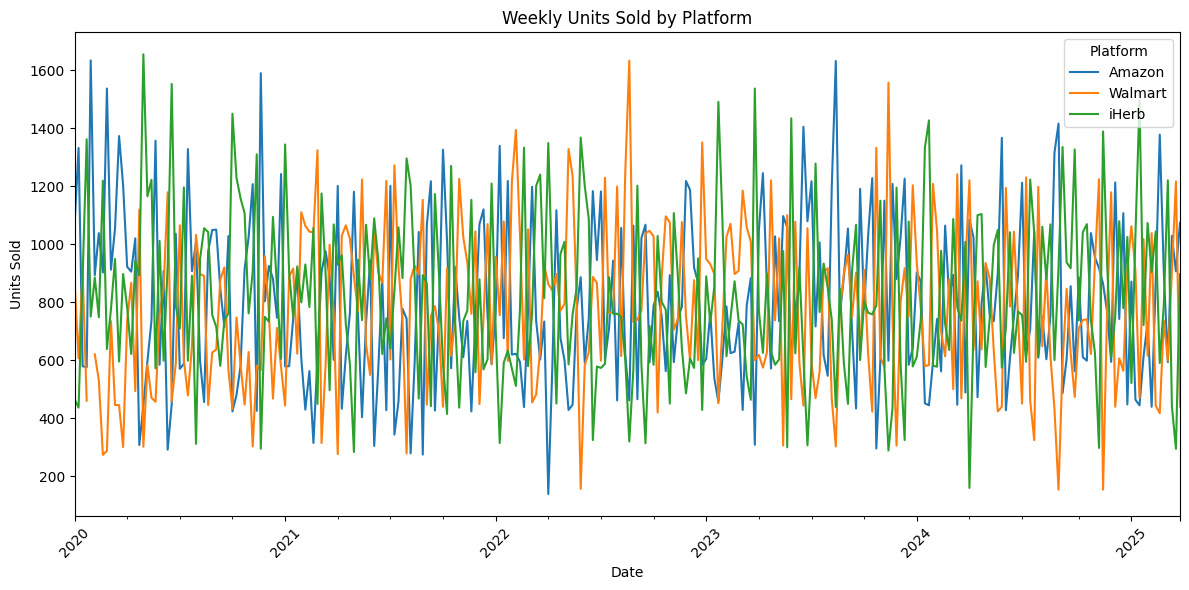

In [32]:
platform_trend = df.groupby(["Date", "Platform"])["Units Sold"].sum().unstack()

platform_trend.plot(figsize=(12,6))
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Weekly Units Sold by Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Time-based Features

In [33]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

### 3.1 Total Units Sold by Month

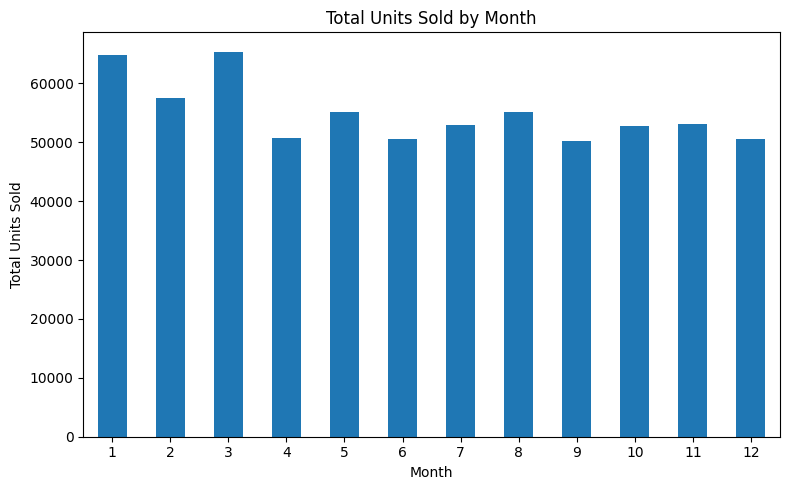

In [34]:
monthly_sales = df.groupby("Month")["Units Sold"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind="bar")
plt.ylabel("Total Units Sold")
plt.title("Total Units Sold by Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Statistical Analysis

### 4.1 CLT

<Axes: ylabel='Count'>

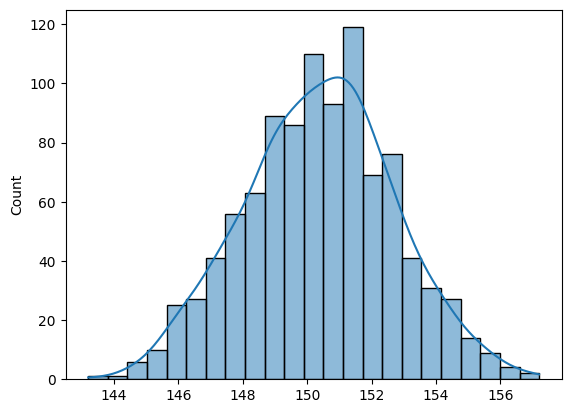

In [35]:
sample_means = []

for i in range(1000):
    sample = df['Units Sold'].sample(30, replace=True)
    sample_means.append(sample.mean())

sns.histplot(sample_means, kde=True)

### 4.2 Hypothesis Testing for Differences in Platform Sales
H0: Sales volume is the same across different platforms.
(ANOVA)

In [36]:
from scipy.stats import f_oneway

groups = [g['Units Sold'].values for name, g in df.groupby('Platform')]

f_oneway(*groups)

F_onewayResult(statistic=np.float64(1.2957408718268268), pvalue=np.float64(0.27379988401398014))

### 4.3 Hypothesis Testing on the Impact of Discounts on Sales
H0: Discounts are unrelated to sales volume.(Spearman correlation)

In [37]:
from scipy.stats import spearmanr

spearmanr(df['Discount'], df['Units Sold'])

SignificanceResult(statistic=np.float64(-0.010868111756919728), pvalue=np.float64(0.47188643949597503))

### 4.4 Bootstrapping

In [38]:
boot_means = []

for i in range(1000):
    sample = df['Units Sold'].sample(frac=1, replace=True)
    boot_means.append(sample.mean())

np.percentile(boot_means, [2.5,97.5])

array([149.82888344, 150.55360972])